In [1]:
import os
import pandas as pd
from plotnine import * 
from matplotlib_venn import venn2
from utils import *
import patchworklib as pw 

point_size = 3
font_size =40

<Figure size 72x72 with 0 Axes>

## S1

In [3]:
#Set working directory
working_dir ="TF_Positional_Distribution_Model/data/ENCODE/"
os.chdir(working_dir)


In [4]:
## Test inverse squared + uniform mixture model
def invsqr_law_model(x, A, k, c):
    return (A/(x**2)) + c

compiled_power_law = pd.DataFrame()
compiled_df= pd.read_csv('processed/Compiled_accessible_target_ChIP_peaks.csv', index_col =0)


for tf in compiled_df.TF.unique():
    for cellLine in compiled_df.CellLine.unique():
        df = compiled_df.loc[(compiled_df.TF == tf) &
                            (compiled_df.CellLine == cellLine)]
        
        #Extract intervals and distribution
        xdata = df['interval']
        y= [df['cumulative'][idx]- df['cumulative'][idx -1] for idx in range(1, df.shape[0])]

        # Fit inv square law + uniform model
        popt1, pcov1 = curve_fit(invsqr_law_model, xdata[1:], y, p0 =[1000,2,0], maxfev = 10000)
        pred = invsqr_law_model(xdata, popt1[0], popt1[1],popt1[2])
        pred_cumulative = np.cumsum(pred[1:])
        
        #Add prediction for inv square law + uniform and compile
        df = df.loc[df.interval!=0]
        df['Prediction_PL'] = pred_cumulative
        compiled_power_law = pd.concat([compiled_power_law,df])
        
        
compiled_power_law['cumulative_max'] = compiled_power_law.groupby(['TF','CellLine'])['cumulative'].transform(max)
compiled_power_law['cumulative_scaled'] = compiled_power_law.groupby(['TF','CellLine'])['cumulative'].transform(lambda x: x/x.max())
compiled_power_law['predicted_scaled'] = compiled_power_law['Prediction']/compiled_power_law['cumulative_max'] 
compiled_power_law['predicted_PL_scaled'] = compiled_power_law['Prediction_PL']/compiled_power_law['cumulative_max'] 

inv_sq = (ggplot(compiled_power_law)
+ geom_point(aes(x='cumulative_scaled',y= 'predicted_PL_scaled', fill = 'TF'), size = point_size, alpha = 0.6)


 +geom_line(aes(x='cumulative_scaled', y='cumulative_scaled'))
+ theme_classic()
+xlab('Observed')
+ylab('Predicted')
+ scale_fill_discrete(guide=False)
+ggtitle('Inverse square law + \nuniform\n')
+ theme(figure_size=(12,8), text=element_text(size=font_size),axis_title_y=element_blank(),
        axis_text = element_text(size=32)))

In [5]:
params= pd.read_csv('processed/ExpDecayConst_params.csv', index_col =0)

df= pd.read_csv('processed/Compiled_accessible_target_ChIP_peaks.csv', index_col =0)
df = df.merge(params,on=['TF','CellLine'])

#Estimate values
df['Estimated true'] = df.apply(lambda x: model_true(x.interval,x.rb,x.tau,x.rs), axis =1 )
df['Fit'] = df.apply(lambda x: model(x.interval,x.rb,x.tau,x.rs),  axis =1 )

#Calculate threshold within which true binding to spurious binding ratio is 10. 
df['true_spur_5'] = df.apply(lambda x: n_max_true(x.rb,x.tau,x.rs, [0.1]).Distance , axis =1)


### A. Plot fits for MCF7 HepG2 and GM12878

In [6]:
tfs = ['CTCF','MYC','MAX','MAZ','SIN3A']
cut= df.loc[df.CellLine == 'GM12878'].groupby(['TF'])['true_spur_5'].mean().mean()
ai=(ggplot(df.loc[(df.CellLine == 'GM12878') & (df.TF.isin(tfs))])
+ geom_line(aes(x='interval/1000', y= 'cumulative/1000', color = 'TF'), size = 4)
+geom_line(aes(x='interval/1000', y= 'Fit/1000', group = 'TF'),size = 2, alpha = 0.7, linetype = 'dashed')
+ theme_classic()
+geom_vline(xintercept = cut/1000, colour="red", linetype = "dashed", size=2)
+xlab('')
+ylab('Number of \n accessible peaks\n(thousands)')
+ggtitle('GM12878')
+ scale_color_discrete(guide=False)
+ theme(figure_size=(12,8), text=element_text(size=font_size), panel_spacing = 10 ))

cut= df.loc[df.CellLine == 'HepG2'].groupby(['TF'])['true_spur_5'].mean().mean()
aii = (ggplot(df.loc[(df.CellLine == 'HepG2') & (df.TF.isin(tfs))])
+ geom_line(aes(x='interval/1000', y= 'cumulative/1000', color  = 'TF'), size = 4)
+geom_line(aes(x='interval/1000', y= 'Fit/1000', group = 'TF'),size = 2, alpha = 0.7, linetype = 'dashed')

+ theme_classic()
+geom_vline(xintercept = cut/1000, colour="red", linetype = "dashed", size=2)
+xlab('')
+ylab('Number of \n accessible peaks\n(thousands)')
+ggtitle('HepG2')
+ scale_color_discrete(guide=False)
+ theme(figure_size=(12,8), text=element_text(size=font_size), panel_spacing = 10 ))

cut= df.loc[df.CellLine == 'MCF-7'].groupby(['TF'])['true_spur_5'].mean().mean()
aiii = (ggplot(df.loc[(df.CellLine == 'MCF-7') & (df.TF.isin(tfs))])
+ geom_line(aes(x='interval/1000', y= 'cumulative/1000', color  = 'TF'), size = 4)
+geom_line(aes(x='interval/1000', y= 'Fit/1000', group = 'TF'),size = 2, alpha = 0.7, linetype = 'dashed')
+ theme_classic()
+geom_vline(xintercept = cut/1000, colour="red", linetype = "dashed", size=2)
+xlab('Distance from TSS (kbp)')
+ylab('Number of \n accessible peaks\n(thousands)')
+ggtitle('MCF-7')
+ scale_fill_discrete()
+ theme(figure_size=(12,8), text=element_text(size=font_size), panel_spacing = 10 ,
       legend_position='bottom', legend_direction = 'horizontal'))

In [7]:
ai = pw.load_ggplot(ai, figsize=(9,5))
aii = pw.load_ggplot(aii, figsize=(9,5))
aiii = pw.load_ggplot(aiii, figsize=(9,5))
inv_sq = pw.load_ggplot(inv_sq, figsize=(9,5))

ai.set_index('(a)',size = 38,fontweight="bold" )
aii.set_index('(b)',size = 38,fontweight="bold" )
aiii.set_index('(c)',size = 38,fontweight="bold" )
inv_sq.set_index('(d)',size = 38,fontweight="bold" )
a = ai/aii/aiii/inv_sq


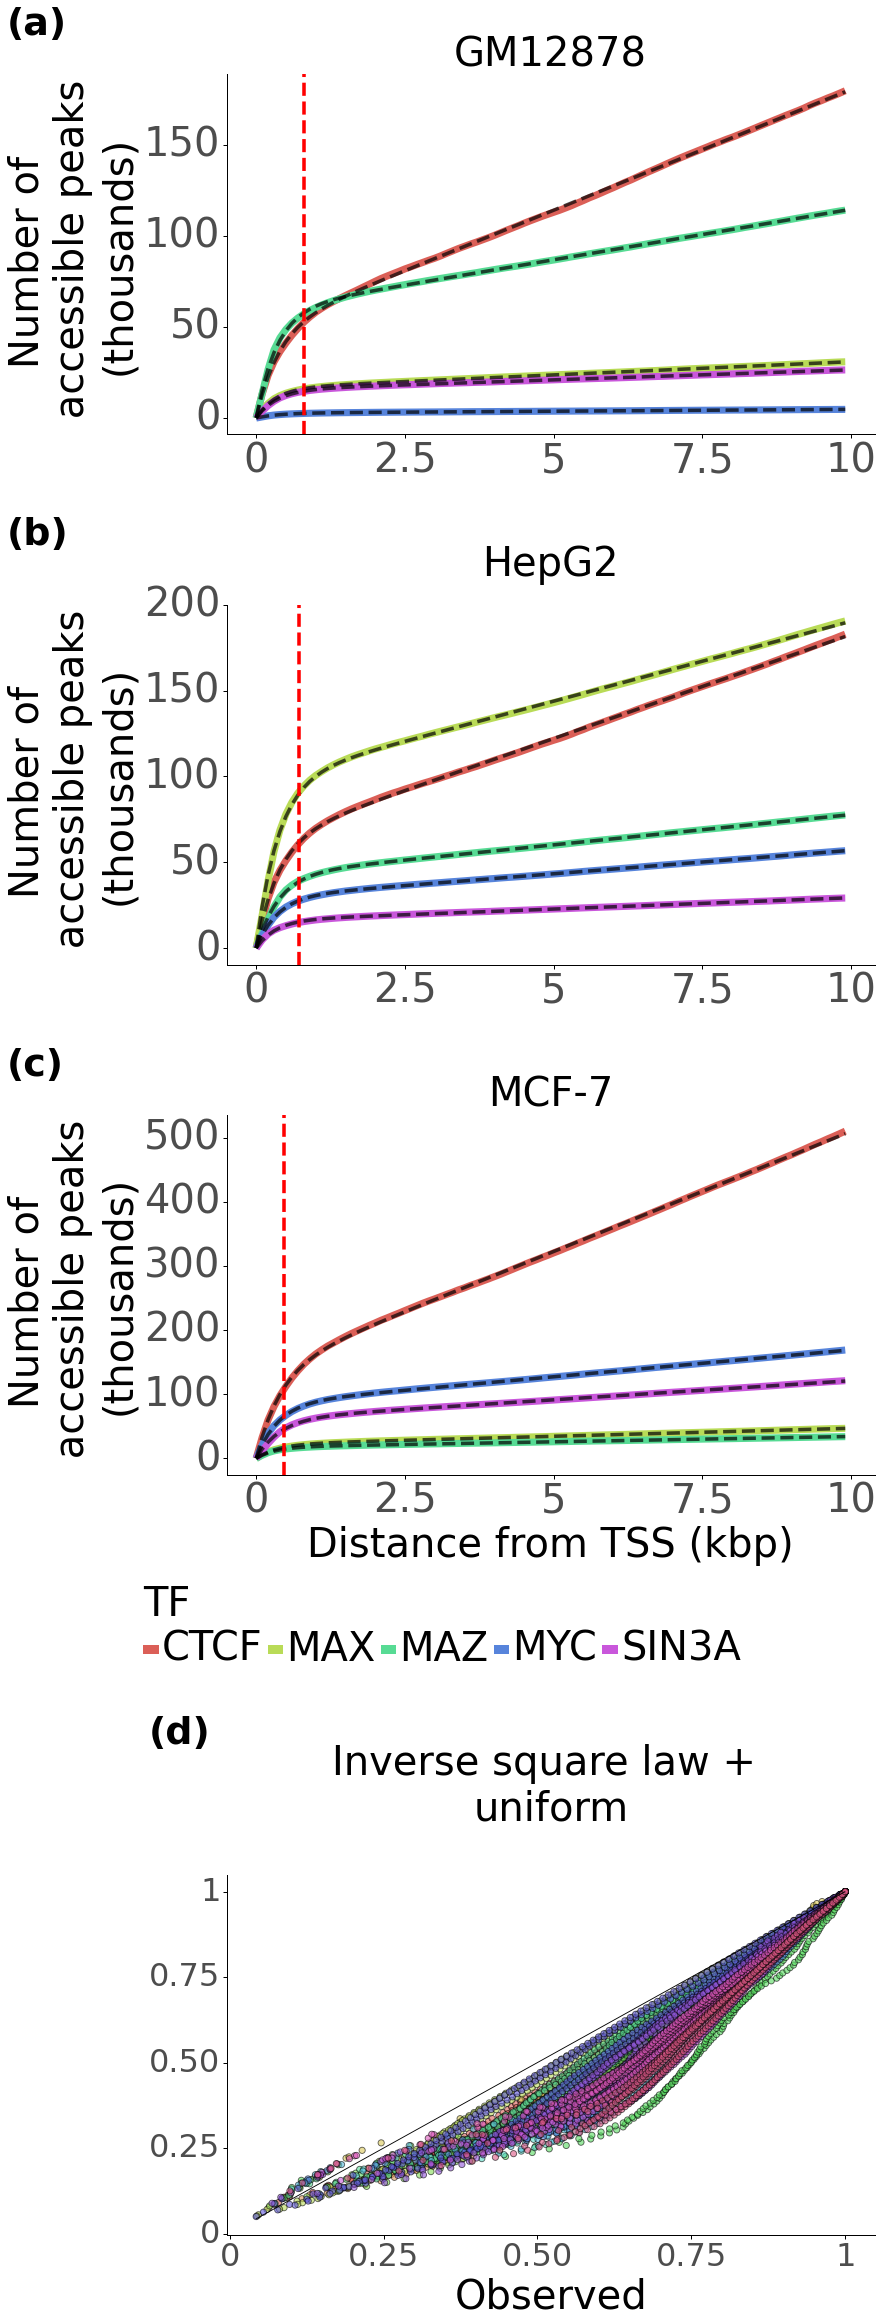

In [8]:
a.savefig('../../Figures/SFig5.pdf')

### B. Generate distributions for model parameters

In [7]:
#Calculate x_0 for each TF-Cell line
params['Threshold'] = params.apply(lambda x: n_max_true(x.rb, x.tau,x.rs,[0.1]).Distance.values[0],axis = 1)

params = pd.melt(params, id_vars=['TF', 'CellLine'], value_vars=['rb','tau','rs','Threshold'])

In [8]:
#Estimate survival function for r_b
params_rb = params.loc[params.variable =='rb'].sort_values(by='value',ascending=False)
params_rb['cumulative'] = range(1,params_rb.shape[0] + 1)
params_rb['survival'] = params_rb['cumulative']/(params_rb.shape[0])
dist_rb =(ggplot(params_rb)
+geom_line(aes(x='value', y='survival'), color = 'salmon', size = 4)
+theme_classic()
+theme(text=element_text(size=font_size), 
      axis_text_x=element_text(rotation=45),
      strip_background = element_blank(), strip_text = element_blank())
+xlab('$r_b$')
+scale_x_log10()
+ylab('$S(r_b)$'))


dist_tau = (ggplot(params.loc[params.variable=='tau'])
+geom_histogram(aes(x='value'), bins = 20, fill='salmon')
+theme_classic()
+theme(text=element_text(size=font_size), 
      axis_text_x=element_text(rotation=45),
      strip_background = element_blank(), strip_text = element_blank())
+xlab('$τ$')
+ylab('Frequency'))


dist_x0 = (ggplot(params.loc[params.variable=='Threshold'])
+geom_histogram(aes(x='value'), bins = 20, fill='salmon')
+theme_classic()
+theme(text=element_text(size=font_size), 
      axis_text_x=element_text(rotation=45),
      strip_background = element_blank(), strip_text = element_blank())
+xlab('$x_0$')
+ylab('Frequency'))


#Estimate survival function for r_s
params_rs = params.loc[params.variable =='rs'].sort_values(by='value',ascending=False)
params_rs['cumulative'] = range(1,params_rs.shape[0] + 1)
params_rs['survival'] = params_rs['cumulative']/(params_rs.shape[0])
dist_rs =(ggplot(params_rs)
+geom_line(aes(x='value', y='survival'), color = 'salmon', size = 4)
+theme_classic()
+theme(text=element_text(size=font_size), 
      axis_text_x=element_text(rotation=45),
      strip_background = element_blank(), strip_text = element_blank())
+scale_x_log10()
+xlab('$r_s$')
+ylab('$S(r_s)$'))


### C. Variation in parameters across cell lines

In [9]:
var_rb = (ggplot(params.loc[params.variable=='rb'])
+geom_boxplot(aes(x = 'TF',y='value'), size =1.5,color = 'black', fill='salmon')
+theme_classic()
+theme( axis_text_x=element_text(rotation=45, va="top", ha="right", rotation_mode="anchor"),
       text=element_text(size=font_size), strip_background = element_blank(), strip_text = element_blank())
+ylab('$r_b$')
+scale_y_log10()
 +annotation_stripes(
    fill=("#FFFFFF", "#DDDDDD")))

var_tau = (ggplot(params.loc[params.variable=='tau'])
+geom_boxplot(aes(x = 'TF',y='value'), size =1.5,color = 'black', fill='salmon')
+theme_classic()
+theme( axis_text_x=element_text(rotation=45, va="top", ha="right", rotation_mode="anchor"),
       text=element_text(size=font_size), strip_background = element_blank(), strip_text = element_blank())
+annotation_stripes(
    fill=("#FFFFFF", "#DDDDDD"))    
+ylab('$τ$'))

var_rs = (ggplot(params.loc[params.variable=='rs'])
+geom_boxplot(aes(x = 'TF',y='value'), size =1.5,color = 'black', fill='salmon')
+theme_classic()
+theme( axis_text_x=element_text(rotation=45, va="top", ha="right", rotation_mode="anchor"),
       text=element_text(size=font_size), strip_background = element_blank(), strip_text = element_blank())
+ylab('$r_s$')
+scale_y_log10()
+annotation_stripes(
    fill=("#FFFFFF", "#DDDDDD")))

var_x0 = (ggplot(params.loc[params.variable=='Threshold'])
+geom_boxplot(aes(x = 'TF',y='value'), size =1.5,color = 'black', fill='salmon')
+theme_classic()
+theme( axis_text_x=element_text(rotation=45, va="top", ha="right", rotation_mode="anchor"),
       text=element_text(size=font_size), strip_background = element_blank(), strip_text = element_blank())
+annotation_stripes(
    fill=("#FFFFFF", "#DDDDDD"))    
+ylab('$x_0$'))

In [10]:
dist_rb = pw.load_ggplot(dist_rb, figsize=(12,8))
var_rb = pw.load_ggplot(var_rb, figsize=(12,8))
dist_rb.set_index('(a)',size = 38,fontweight="bold" )
var_rb.set_index('(b)',size = 38,fontweight="bold" )

dist_tau = pw.load_ggplot(dist_tau, figsize=(12,8))
var_tau = pw.load_ggplot(var_tau, figsize=(12,8))
dist_tau.set_index('(a)',size = 38,fontweight="bold" )
var_tau.set_index('(b)',size = 38,fontweight="bold" )


dist_rs = pw.load_ggplot(dist_rs, figsize=(12,8))
var_rs = pw.load_ggplot(var_rs, figsize=(12,8))
dist_rs.set_index('(a)',size = 38,fontweight="bold" )
var_rs.set_index('(b)',size = 38,fontweight="bold" )

dist_x0 = pw.load_ggplot(dist_x0, figsize=(12,8))
var_x0 = pw.load_ggplot(var_x0, figsize=(12,8))
dist_x0.set_index('(a)',size = 38,fontweight="bold" )
var_x0.set_index('(b)',size = 38,fontweight="bold" )

Text(-0.0, 1.0, '(b)')

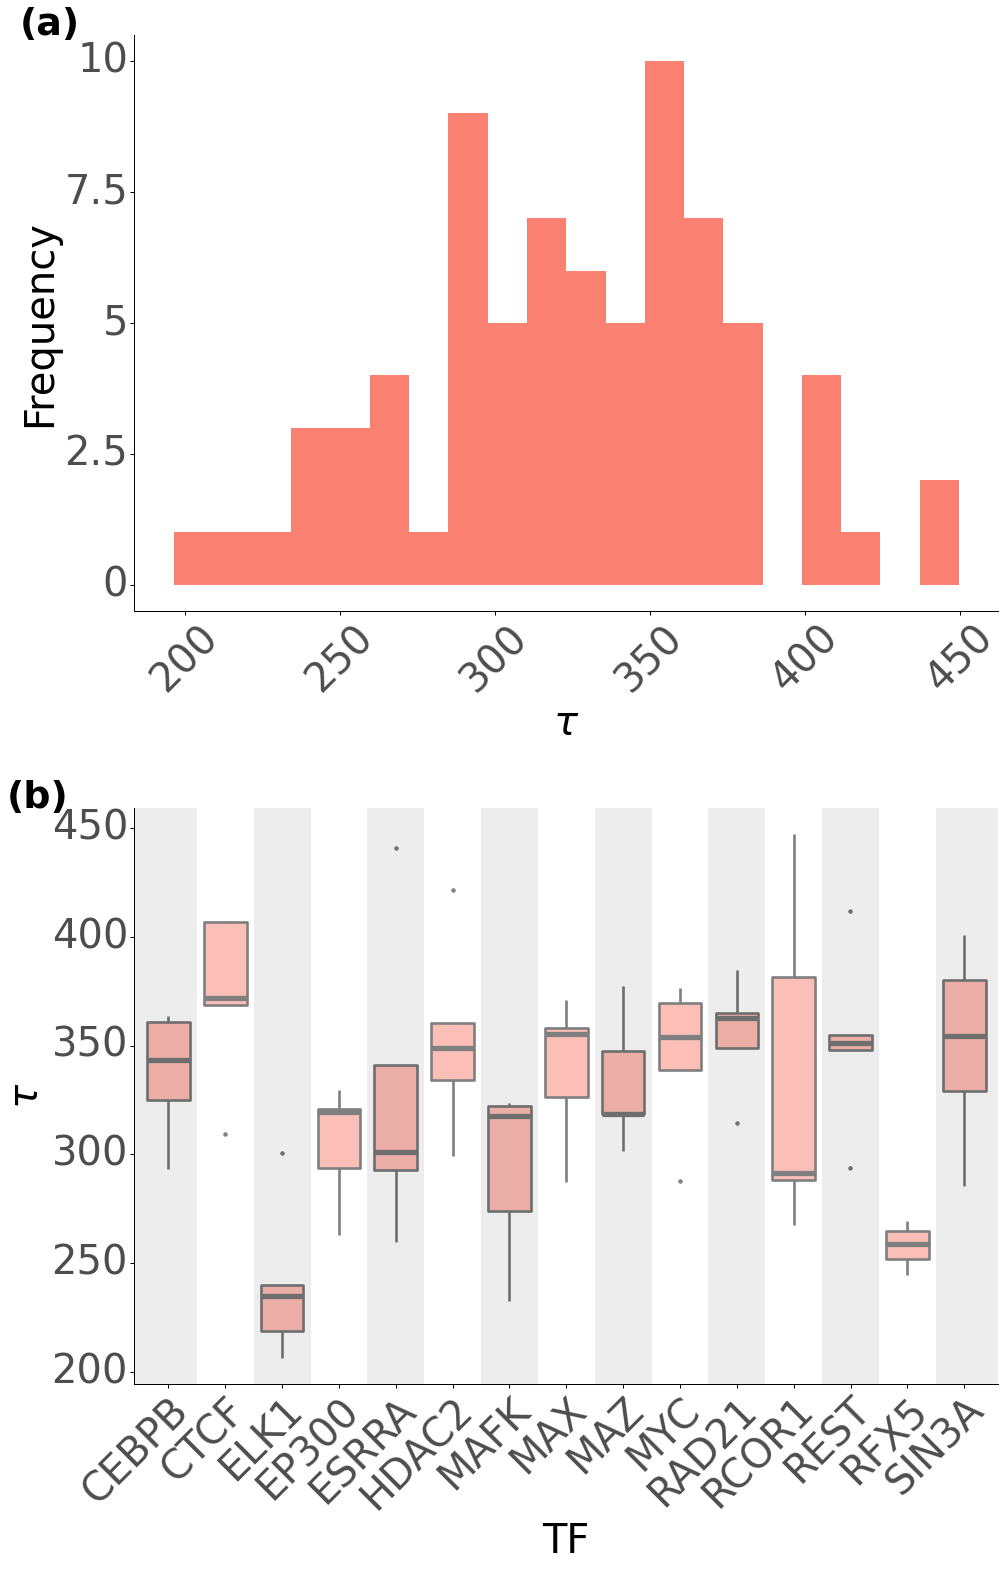

In [11]:
s6 = dist_rb/var_rb
s6.savefig('../../Figures/SFig6.pdf')
s7= dist_rs/var_rs
s7.savefig('../../Figures/SFig7.pdf')
s8 = dist_tau/var_tau
s8.savefig('../../Figures/SFig8.pdf')
s9 = dist_x0/var_x0
s9.savefig('../../Figures/SFig9.pdf')

## S10

In [2]:
#Read reference file
names =['chr','start','end','Gene']
ref= pd.read_table('TF_TSS_10kb_named.bed', names= names)
ref['TSS'] = ref['start'] + 10000



params_cons =[]

#Run across all thresholds
for i in range(1,10):
    files = os.listdir('1e-' + str(i))
    #Select files for target genes within 10kb of TSS
    files = [f for f in files if '.narrowPeak_targets_10k.bed' in f ]
    #Read files for each threshold
    for f in files: 
        file='1e-' + str(i) + '/' + f
        
        #Check than number of lines >0
        with open(file, 'r') as f:
            lines = len(f.readlines())
        
        if lines > 10:
            #Extract parameters
            params_cons.append(read_extract_params(file, ref = ref ) + [file.split('/')[1].split('_1e')[0],'1e-' + str(i)])

params_cons = pd.DataFrame(params_cons, columns =['A','k','c', 'name','p'])

In [3]:
font_size=44
f1=(ggplot(params_cons)
+geom_boxplot(aes(x='p',y='c',fill = 'p'), show_legend= False)
+geom_jitter(aes(x='p',y='c',fill = 'p'), show_legend= False)
+scale_y_log10()
+theme_classic()
+theme( text=element_text(size=font_size), axis_text_x = element_blank())
+xlab('')
+ylab('$r_s$')
+scale_fill_brewer(palette = 'Blues'))

f2 = (ggplot(params_cons)
+geom_boxplot(aes(x='p',y='A',fill = 'p'), show_legend= False)
+geom_jitter(aes(x='p',y='A',fill = 'p'), show_legend= False)
+scale_y_log10()
+theme_classic()
+theme( text=element_text(size=font_size), axis_text_x = element_blank())
+xlab('')
+ylab('$r_b$')
+scale_fill_brewer(palette = 'Blues'))


f3 = (ggplot(params_cons)
+geom_boxplot(aes(x='p',y='1/k',fill = 'p'))
+geom_jitter(aes(x='p',y='1/k',fill = 'p'))
+scale_y_log10()
+theme_classic()
+theme( text=element_text(size=font_size), axis_text_x = element_blank(),
      legend_position='bottom', legend_direction = 'horizontal')
+guides(fill = guide_legend(nrow = 1, order =1,override_aes={"shape": 's', 'size': 8} )) 
+xlab('')
+ylab('$τ$')
+scale_fill_brewer(palette = 'Blues'))



In [4]:
f1 = pw.load_ggplot(f1, figsize=(12,8))
f1.set_index('(a)',size = 38,fontweight="bold" )
f2 = pw.load_ggplot(f2, figsize=(12,8))
f2.set_index('(b)',size = 38,fontweight="bold" )
f3 = pw.load_ggplot(f3, figsize=(12,8))
f3.set_index('(c)',size = 38,fontweight="bold" )


s10 = f1/f2/f3

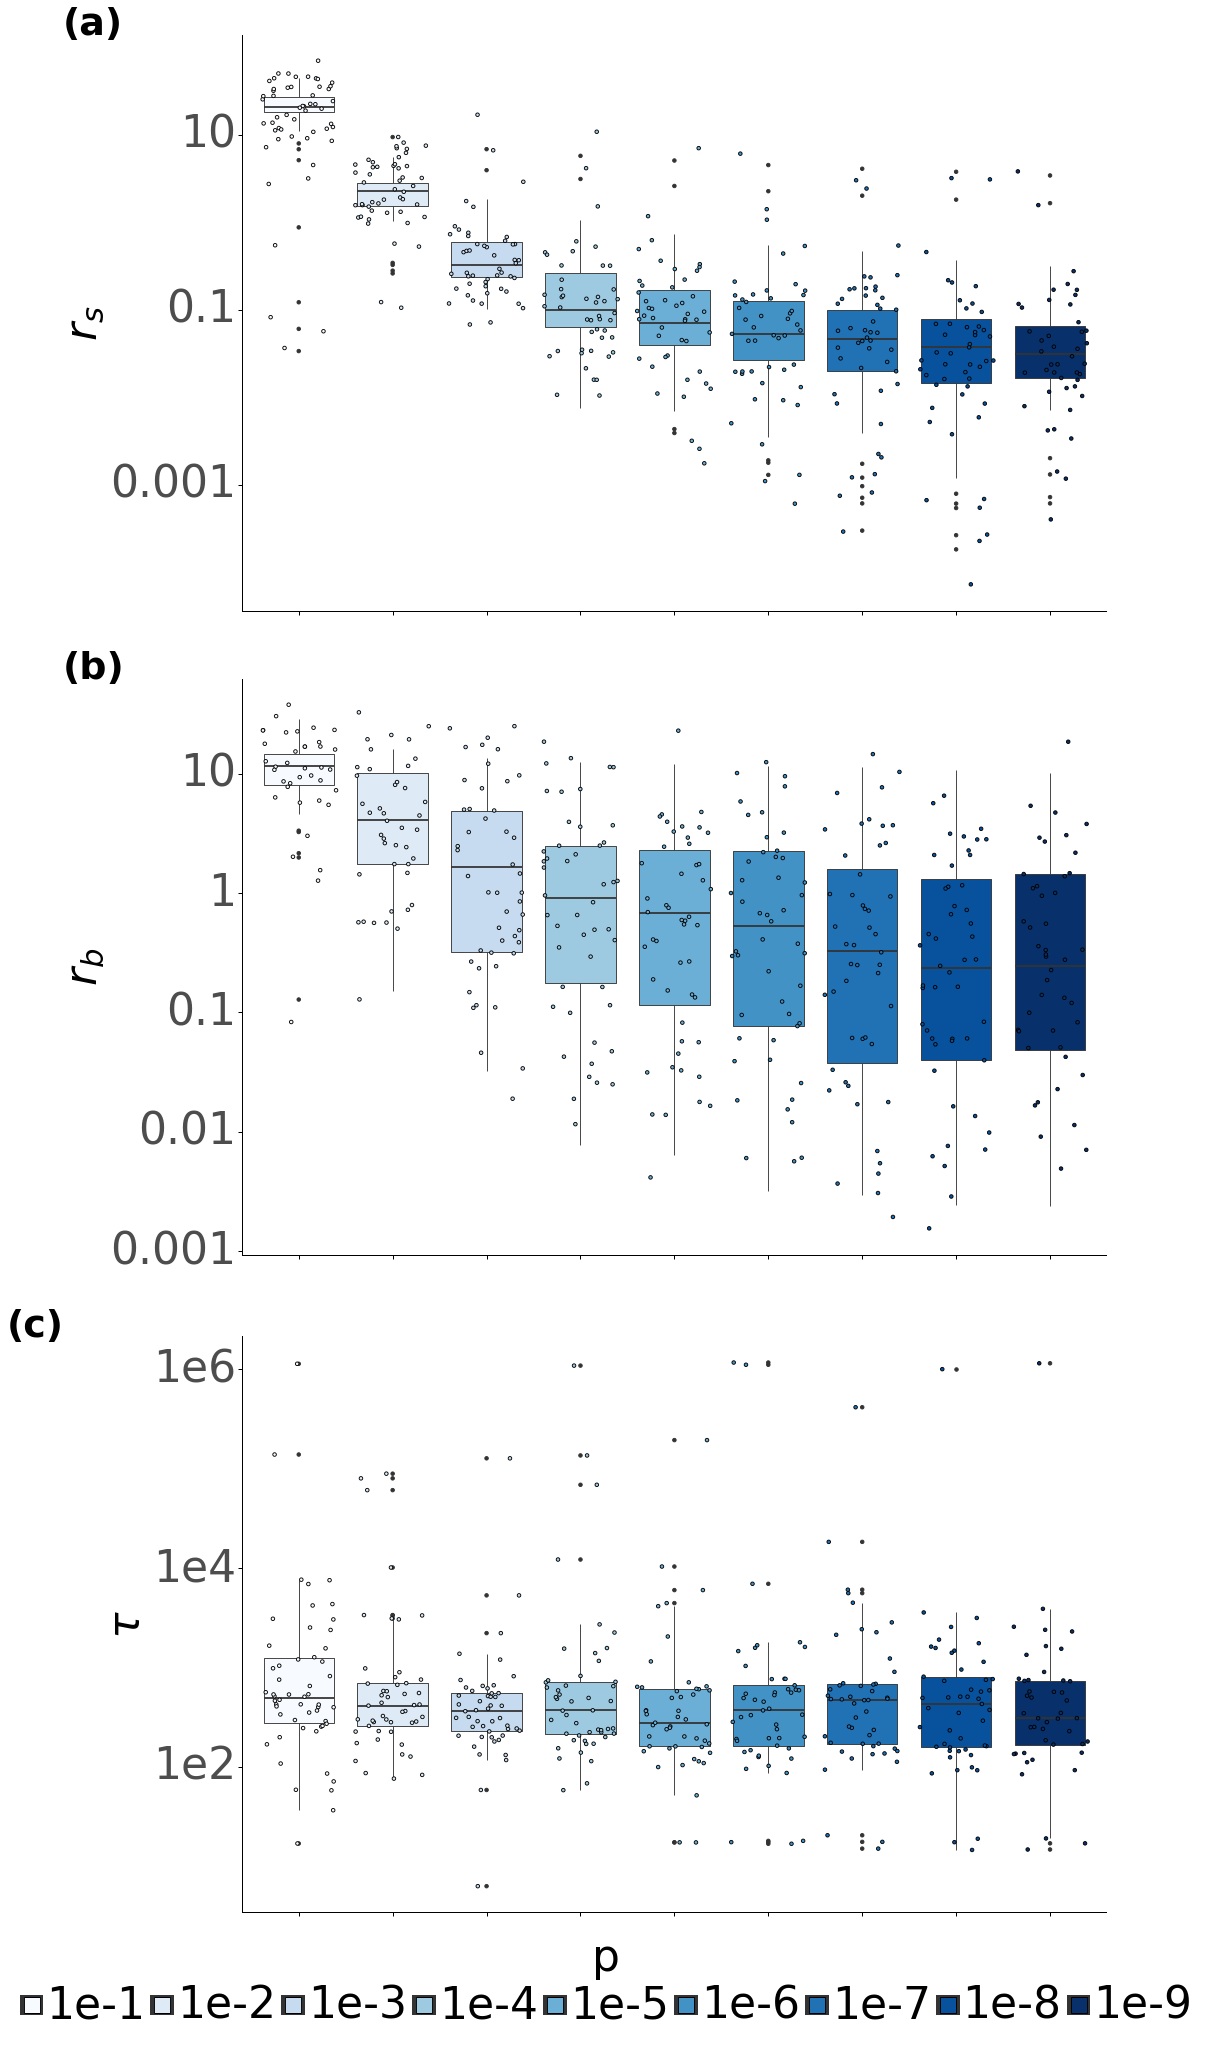

In [5]:
s10.savefig('../../Figures/SFig10.pdf')